# Phase 1: Data Sanity Checks

This notebook validates the synthetic data generators for the PPA Valuation Engine, making sure it is suited to the hypothetical scenario and core assumptions outlined in the project overview.

**Data Series:**
1. Solar Production (50 MW asset, Utrecht NL)
2. Market Prices (EPEX NL day-ahead)
3. Consumer Load (100 GWh/year industrial offtaker)

**Horizon:** 2027-01-01 to 2036-12-31 (10 years)

In [18]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ppa_engine.config import PPAConfig
from ppa_engine.data.solar_production import generate_solar_production
from ppa_engine.data.market_prices import generate_market_prices
from ppa_engine.data.consumer_load import generate_consumer_load

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

In [19]:
# Generate all data series
config = PPAConfig()

print(f"Generating data for horizon: {config.deal.start_date} to {config.deal.end_date}")
print(f"Location: {config.location.lat}N, {config.location.lon}E (Utrecht, NL)")
print(f"Solar capacity: {config.solar.capacity_mw} MW")
print(f"Consumer load: {config.load.annual_consumption_gwh} GWh/year")

solar = generate_solar_production(config)
prices = generate_market_prices(config)
load = generate_consumer_load(config)

print(f"\nGenerated {len(solar):,} hourly observations")

Generating data for horizon: 2027-01-01 to 2036-12-31
Location: 52.1N, 5.1E (Utrecht, NL)
Solar capacity: 50.0 MW
Consumer load: 100.0 GWh/year

Generated 87,672 hourly observations


---
## 1. Solar Production Checks

**Targets:**
- Annual yield: 900-1,000 kWh/kWp
- Capacity factor: 10-12%
- Night-time output: ~0 MWh
- Visible weather persistence (good/bad weeks)

In [20]:
# Annual statistics
capacity_mw = config.solar.capacity_mw
capacity_kwp = capacity_mw * 1000

annual_mwh = solar.groupby(solar.index.year).sum()
annual_yield = annual_mwh * 1000 / capacity_kwp  # kWh/kWp
capacity_factor = annual_mwh / (capacity_mw * 8760) * 100

print("SOLAR PRODUCTION - Annual Statistics")
print("=" * 50)
print(f"{'Year':<6} {'Production':>12} {'Yield':>14} {'CF':>8}")
print(f"{'':6} {'(GWh)':>12} {'(kWh/kWp)':>14} {'(%)':>8}")
print("-" * 50)
for year in annual_mwh.index:
    print(f"{year:<6} {annual_mwh[year]/1000:>12.1f} {annual_yield[year]:>14.0f} {capacity_factor[year]:>8.1f}")
print("-" * 50)
print(f"{'Mean':<6} {annual_mwh.mean()/1000:>12.1f} {annual_yield.mean():>14.0f} {capacity_factor.mean():>8.1f}")

# Sanity check assertions
yield_ok = 850 <= annual_yield.mean() <= 1050
cf_ok = 9 <= capacity_factor.mean() <= 13
print(f"\nYield check (900-1000 kWh/kWp): {'PASS' if yield_ok else 'FAIL'} ({annual_yield.mean():.0f} kWh/kWp)")
print(f"CF check (10-12%): {'PASS' if cf_ok else 'FAIL'} ({capacity_factor.mean():.1f}%)")

SOLAR PRODUCTION - Annual Statistics
Year     Production          Yield       CF
              (GWh)      (kWh/kWp)      (%)
--------------------------------------------------
2027           45.3            906     10.3
2028           44.9            898     10.2
2029           46.8            936     10.7
2030           44.9            899     10.3
2031           43.3            865      9.9
2032           43.3            866      9.9
2033           43.6            872     10.0
2034           44.4            888     10.1
2035           43.6            871      9.9
2036           43.1            862      9.8
--------------------------------------------------
Mean           44.3            886     10.1

Yield check (900-1000 kWh/kWp): PASS (886 kWh/kWp)
CF check (10-12%): PASS (10.1%)


In [21]:
# Night-time generation check
night_hours = solar[(solar.index.hour < 5) | (solar.index.hour > 21)]
night_max = night_hours.max()
night_total = night_hours.sum()

print(f"Night-time (00:00-05:00, 22:00-23:00) generation:")
print(f"  Max hourly: {night_max:.4f} MWh")
print(f"  Total: {night_total:.2f} MWh ({night_total/solar.sum()*100:.3f}% of total)")
print(f"  Check (max < 0.1 MWh): {'PASS' if night_max < 0.1 else 'FAIL'}")

Night-time (00:00-05:00, 22:00-23:00) generation:
  Max hourly: 0.0006 MWh
  Total: 0.04 MWh (0.000% of total)
  Check (max < 0.1 MWh): PASS


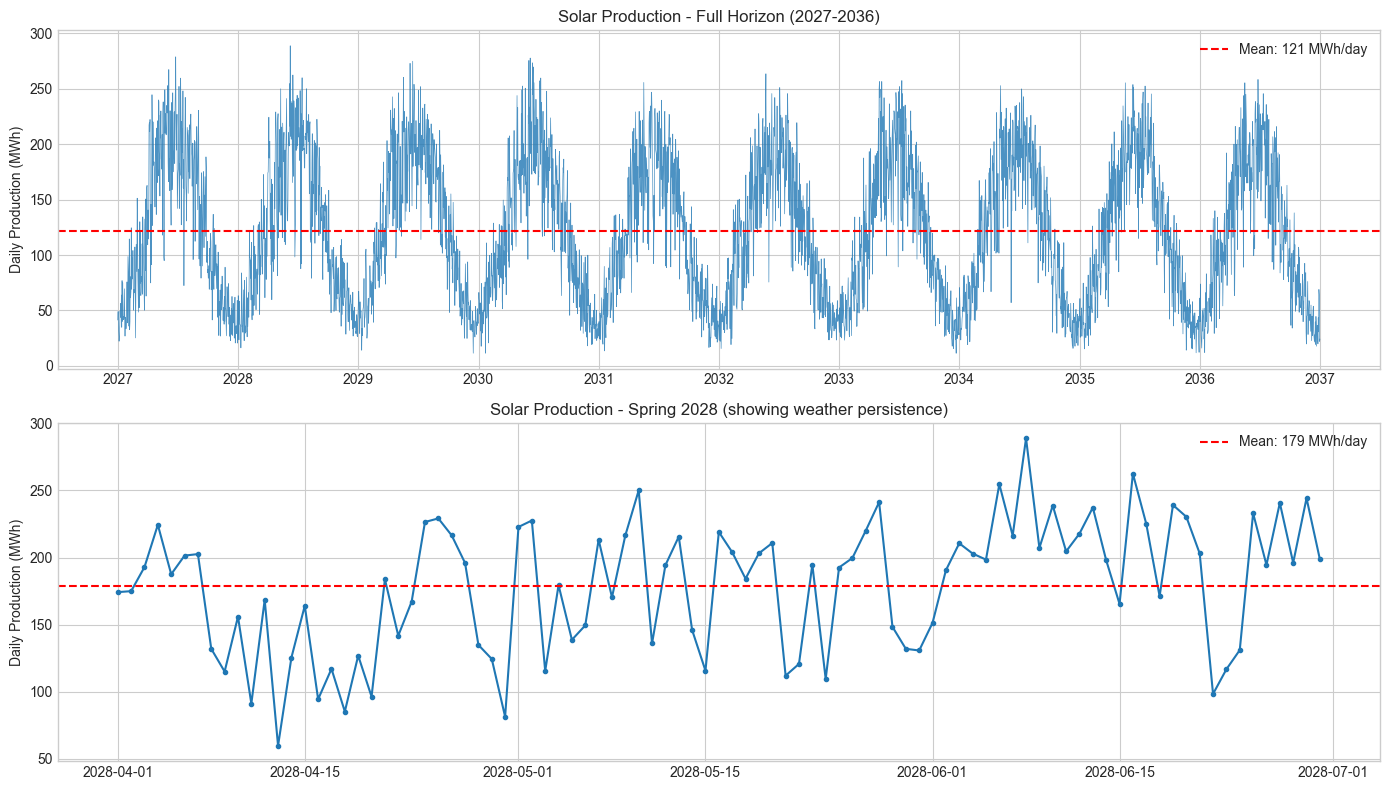

In [22]:
# Plot: Daily solar production showing weather persistence
daily_solar = solar.resample('D').sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full horizon
axes[0].plot(daily_solar.index, daily_solar.values, linewidth=0.5, alpha=0.8)
axes[0].set_ylabel('Daily Production (MWh)')
axes[0].set_title('Solar Production - Full Horizon (2027-2036)')
axes[0].axhline(daily_solar.mean(), color='red', linestyle='--', label=f'Mean: {daily_solar.mean():.0f} MWh/day')
axes[0].legend()

# Zoom: 3 months in 2028 to show weather persistence
zoom = daily_solar['2028-04':'2028-06']
axes[1].plot(zoom.index, zoom.values, linewidth=1.5, marker='o', markersize=3)
axes[1].set_ylabel('Daily Production (MWh)')
axes[1].set_title('Solar Production - Spring 2028 (showing weather persistence)')
axes[1].axhline(zoom.mean(), color='red', linestyle='--', label=f'Mean: {zoom.mean():.0f} MWh/day')
axes[1].legend()

plt.tight_layout()
plt.show()

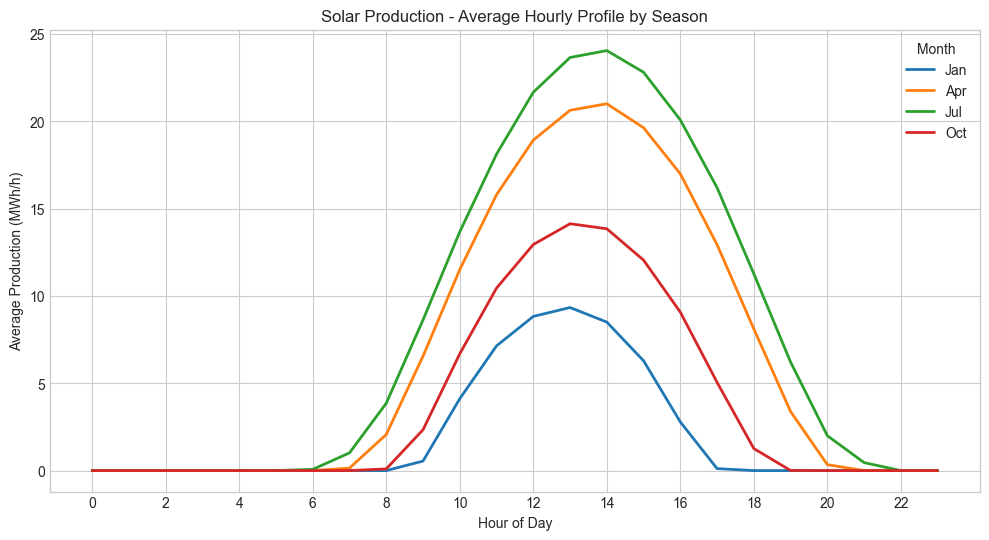

In [23]:
# Plot: Average hourly profile by month
solar_df = solar.to_frame()
solar_df['hour'] = solar_df.index.hour
solar_df['month'] = solar_df.index.month

hourly_by_month = solar_df.groupby(['month', 'hour'])['solar_production_mwh'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(12, 6))
for month in [1, 4, 7, 10]:
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ax.plot(hourly_by_month.index, hourly_by_month[month], label=month_names[month-1], linewidth=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Production (MWh/h)')
ax.set_title('Solar Production - Average Hourly Profile by Season')
ax.legend(title='Month')
ax.set_xticks(range(0, 24, 2))
plt.show()

---
## 2. Market Prices Checks

**Targets:**
- Annual average: ~80 EUR/MWh in 2027, declining to ~60 EUR/MWh by 2036
- Peak hours (17:00-20:00, winter weekdays): 120-150 EUR/MWh
- Solar peak (12:00-14:00, summer): 40-50 EUR/MWh in 2027, negative by 2034
- Weekend nights (summer): 30-50 EUR/MWh
- Capture rate: 0.65-0.85, declining over horizon

In [24]:
# Annual average prices
annual_prices = prices.groupby(prices.index.year).mean()

print("MARKET PRICES - Annual Statistics")
print("=" * 40)
print(f"{'Year':<6} {'Avg Price':>12} {'Min':>10} {'Max':>10}")
print(f"{'':6} {'(EUR/MWh)':>12} {'':>10} {'':>10}")
print("-" * 40)
for year in annual_prices.index:
    yearly = prices[prices.index.year == year]
    print(f"{year:<6} {annual_prices[year]:>12.1f} {yearly.min():>10.1f} {yearly.max():>10.1f}")

print(f"\n2027 avg check (~80 EUR/MWh): {'PASS' if 75 <= annual_prices[2027] <= 85 else 'FAIL'} ({annual_prices[2027]:.1f})")
print(f"2036 avg check (~60 EUR/MWh): {'PASS' if 55 <= annual_prices[2036] <= 70 else 'FAIL'} ({annual_prices[2036]:.1f})")
print(f"Negative prices occur: {'PASS' if prices.min() < 0 else 'FAIL'} (min: {prices.min():.1f} EUR/MWh)")

MARKET PRICES - Annual Statistics
Year      Avg Price        Min        Max
          (EUR/MWh)                      
----------------------------------------
2027           75.6      -12.8      144.6
2028           73.8      -18.1      144.5
2029           72.6      -21.0      146.0
2030           70.1      -20.8      140.4
2031           67.8      -31.2      140.0
2032           66.1      -37.8      138.6
2033           64.0      -44.5      133.8
2034           62.7      -48.0      135.6
2035           60.2      -49.0      142.4
2036           58.7      -56.7      132.3

2027 avg check (~80 EUR/MWh): PASS (75.6)
2036 avg check (~60 EUR/MWh): PASS (58.7)
Negative prices occur: PASS (min: -56.7 EUR/MWh)


In [25]:
# Peak hours check: winter weekdays 17:00-20:00
winter_mask = prices.index.month.isin([1, 2, 12])
weekday_mask = prices.index.dayofweek < 5
peak_mask = prices.index.hour.isin([17, 18, 19])
winter_peak = prices[winter_mask & weekday_mask & peak_mask]

# Solar peak check: summer 12:00-14:00
summer_mask = prices.index.month.isin([6, 7, 8])
solar_peak_mask = prices.index.hour.isin([12, 13])

solar_peak_2027 = prices[(prices.index.year == 2027) & summer_mask & solar_peak_mask]
solar_peak_2034 = prices[(prices.index.year == 2034) & summer_mask & solar_peak_mask]

# Weekend night summer check
weekend_mask = prices.index.dayofweek >= 5
night_mask = prices.index.hour.isin([0, 1, 2, 3, 4])
weekend_summer_night = prices[summer_mask & weekend_mask & night_mask]

print("MARKET PRICES - Segment Analysis")
print("=" * 50)
print(f"Winter peak (17-20h weekdays):    {winter_peak.mean():>6.1f} EUR/MWh (target: 120-150)")
print(f"Solar peak 2027 (12-14h summer):  {solar_peak_2027.mean():>6.1f} EUR/MWh (target: 40-50)")
print(f"Solar peak 2034 (12-14h summer):  {solar_peak_2034.mean():>6.1f} EUR/MWh (expect some negative)")
print(f"Weekend night summer:             {weekend_summer_night.mean():>6.1f} EUR/MWh (target: 30-50)")
print(f"\nNegative prices in 2034 summer solar hours: {(solar_peak_2034 < 0).sum()} occurrences")

MARKET PRICES - Segment Analysis
Winter peak (17-20h weekdays):     115.1 EUR/MWh (target: 120-150)
Solar peak 2027 (12-14h summer):    18.7 EUR/MWh (target: 40-50)
Solar peak 2034 (12-14h summer):   -14.4 EUR/MWh (expect some negative)
Weekend night summer:               44.9 EUR/MWh (target: 30-50)

Negative prices in 2034 summer solar hours: 141 occurrences


In [26]:
# Capture rate calculation
print("CAPTURE RATE by Year")
print("=" * 50)
print(f"{'Year':<6} {'Avg Price':>12} {'Capture Price':>14} {'Capture Rate':>14}")
print("-" * 50)

capture_rates = {}
for year in range(2027, 2037):
    mask = solar.index.year == year
    s = solar[mask]
    p = prices[mask]
    prod_mask = s > 0
    capture_price = (p[prod_mask] * s[prod_mask]).sum() / s[prod_mask].sum()
    avg_price = p.mean()
    capture_rate = capture_price / avg_price
    capture_rates[year] = capture_rate
    print(f"{year:<6} {avg_price:>12.1f} {capture_price:>14.1f} {capture_rate:>14.2f}")

print("-" * 50)
print(f"Target range: 0.65-0.85, declining")
cr_2027_ok = 0.65 <= capture_rates[2027] <= 0.90
cr_2036_ok = 0.60 <= capture_rates[2036] <= 0.80
cr_declining = capture_rates[2036] < capture_rates[2027]
print(f"2027 in range: {'PASS' if cr_2027_ok else 'FAIL'} ({capture_rates[2027]:.2f})")
print(f"2036 in range: {'PASS' if cr_2036_ok else 'FAIL'} ({capture_rates[2036]:.2f})")
print(f"Declining trend: {'PASS' if cr_declining else 'FAIL'}")

CAPTURE RATE by Year
Year      Avg Price  Capture Price   Capture Rate
--------------------------------------------------
2027           75.6           64.1           0.85
2028           73.8           61.1           0.83
2029           72.6           59.6           0.82
2030           70.1           55.5           0.79
2031           67.8           52.5           0.77
2032           66.1           50.0           0.76
2033           64.0           46.6           0.73
2034           62.7           45.0           0.72
2035           60.2           40.6           0.67
2036           58.7           38.5           0.66
--------------------------------------------------
Target range: 0.65-0.85, declining
2027 in range: PASS (0.85)
2036 in range: PASS (0.66)
Declining trend: PASS


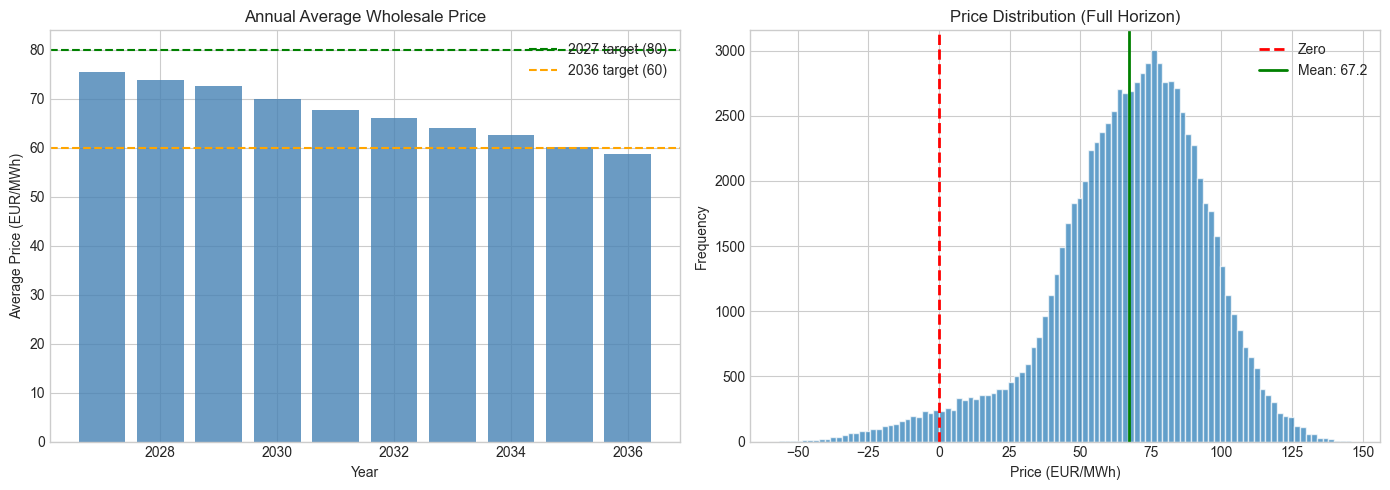

In [27]:
# Plot: Price distribution and annual trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annual average trend
axes[0].bar(annual_prices.index, annual_prices.values, color='steelblue', alpha=0.8)
axes[0].axhline(80, color='green', linestyle='--', label='2027 target (80)')
axes[0].axhline(60, color='orange', linestyle='--', label='2036 target (60)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Price (EUR/MWh)')
axes[0].set_title('Annual Average Wholesale Price')
axes[0].legend()

# Price distribution
axes[1].hist(prices.values, bins=100, edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[1].axvline(prices.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {prices.mean():.1f}')
axes[1].set_xlabel('Price (EUR/MWh)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price Distribution (Full Horizon)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Plot: Average hourly price profile - weekday vs weekend
prices_df = prices.to_frame(name='price')
prices_df['hour'] = prices_df.index.hour
prices_df['is_weekend'] = prices_df.index.dayofweek >= 5

hourly_wd = prices_df[~prices_df['is_weekend']].groupby('hour')['price'].mean()
hourly_we = prices_df[prices_df['is_weekend']].groupby('hour')['price'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_wd.index, hourly_wd.values, label='Weekday', linewidth=2, marker='o')
ax.plot(hourly_we.index, hourly_we.values, label='Weekend', linewidth=2, marker='s')
ax.axhline(prices.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Overall mean: {prices.mean():.1f}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Price (EUR/MWh)')
ax.set_title('Average Hourly Price Profile')
ax.set_xticks(range(0, 24))
ax.legend()
ax.fill_between([12, 14], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.2, color='yellow', label='Solar peak')
plt.show()

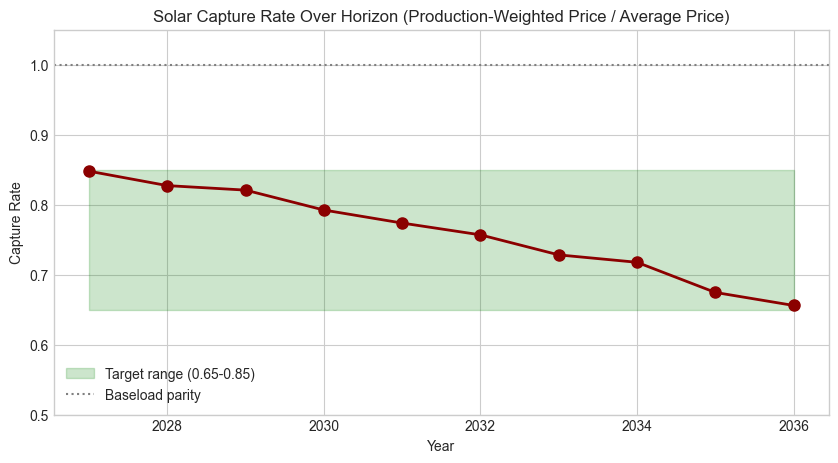

In [ ]:
# Plot: Capture rate over time
fig, ax = plt.subplots(figsize=(10, 5))
years = list(capture_rates.keys())
rates = list(capture_rates.values())

ax.plot(years, rates, marker='o', linewidth=2, markersize=8, color='darkred')
ax.fill_between([2027, 2036], 0.65, 0.85, alpha=0.2, color='green', label='Target range (0.65-0.85)')
ax.axhline(1.0, color='gray', linestyle=':', label='Baseload parity')
ax.set_xlabel('Year')
ax.set_ylabel('Capture Rate')
ax.set_title('Solar Capture Rate Over Horizon (Production-Weighted Price / Average Price)')
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.show()

---
## 3. Consumer Load Checks

**Targets:**
- Annual total: 100 GWh (exact, after rescaling)
- Hourly mean: ~11.4 MWh/h
- Clear weekday/weekend distinction
- Mild seasonal amplitude (~15%)

In [ ]:
# Annual load statistics
annual_load = load.groupby(load.index.year).sum() / 1000  # GWh

print("CONSUMER LOAD - Annual Statistics")
print("=" * 40)
print(f"{'Year':<6} {'Consumption':>12}")
print(f"{'':6} {'(GWh)':>12}")
print("-" * 40)
for year in annual_load.index:
    deviation = (annual_load[year] - 100) / 100 * 100
    print(f"{year:<6} {annual_load[year]:>12.2f} ({deviation:+.2f}%)")

print(f"\nTarget: 100.00 GWh/year")
print(f"Max deviation: {abs(annual_load - 100).max():.2f} GWh ({abs(annual_load - 100).max()/100*100:.2f}%)")
print(f"Check (within 0.1%): {'PASS' if abs(annual_load - 100).max() < 0.1 else 'FAIL'}")
print(f"\nHourly mean: {load.mean():.2f} MWh/h (target: ~11.4)")

CONSUMER LOAD - Annual Statistics
Year    Consumption
              (GWh)
----------------------------------------
2027         100.00 (+0.00%)
2028         100.00 (+0.00%)
2029         100.00 (-0.00%)
2030         100.00 (+0.00%)
2031         100.00 (+0.00%)
2032         100.00 (+0.00%)
2033         100.00 (+0.00%)
2034         100.00 (+0.00%)
2035         100.00 (-0.00%)
2036         100.00 (+0.00%)

Target: 100.00 GWh/year
Max deviation: 0.00 GWh (0.00%)
Check (within 0.1%): PASS

Hourly mean: 11.41 MWh/h (target: ~11.4)


In [ ]:
# Weekday vs Weekend profile
load_df = load.to_frame(name='load')
load_df['hour'] = load_df.index.hour
load_df['is_weekend'] = load_df.index.dayofweek >= 5

hourly_wd = load_df[~load_df['is_weekend']].groupby('hour')['load'].mean()
hourly_we = load_df[load_df['is_weekend']].groupby('hour')['load'].mean()

print("Weekday/Weekend Distinction:")
print(f"  Weekday mean: {hourly_wd.mean():.2f} MWh/h")
print(f"  Weekend mean: {hourly_we.mean():.2f} MWh/h")
print(f"  Ratio (WD/WE): {hourly_wd.mean()/hourly_we.mean():.2f}")
print(f"  Check (ratio > 1.1): {'PASS' if hourly_wd.mean()/hourly_we.mean() > 1.1 else 'FAIL'}")

Weekday/Weekend Distinction:
  Weekday mean: 11.86 MWh/h
  Weekend mean: 10.26 MWh/h
  Ratio (WD/WE): 1.16
  Check (ratio > 1.1): PASS


In [ ]:
# Seasonal amplitude check
monthly_load = load.groupby(load.index.month).mean()
winter = monthly_load[[12, 1, 2]].mean()
summer = monthly_load[[6, 7, 8]].mean()
seasonal_swing = (winter - summer) / load.mean()

print(f"Seasonal Amplitude:")
print(f"  Winter mean (Dec-Feb): {winter:.2f} MWh/h")
print(f"  Summer mean (Jun-Aug): {summer:.2f} MWh/h")
print(f"  Seasonal swing: {seasonal_swing*100:.1f}% (target: ~15%)")

Seasonal Amplitude:
  Winter mean (Dec-Feb): 12.95 MWh/h
  Summer mean (Jun-Aug): 9.87 MWh/h
  Seasonal swing: 27.0% (target: ~15%)


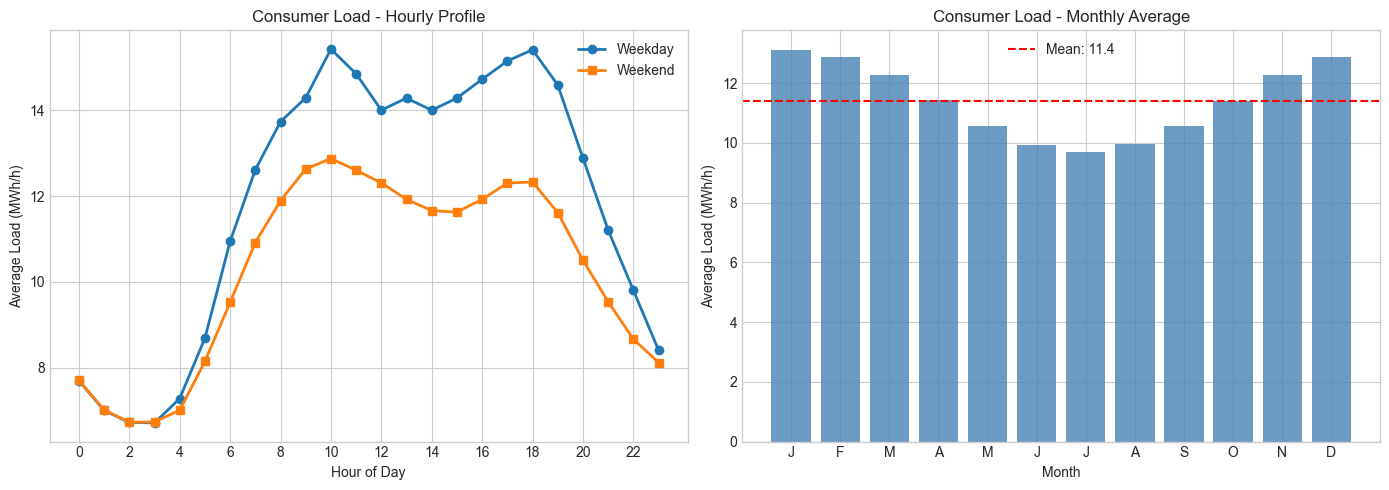

In [ ]:
# Plot: Load profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly profile weekday vs weekend
axes[0].plot(hourly_wd.index, hourly_wd.values, label='Weekday', linewidth=2, marker='o')
axes[0].plot(hourly_we.index, hourly_we.values, label='Weekend', linewidth=2, marker='s')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Load (MWh/h)')
axes[0].set_title('Consumer Load - Hourly Profile')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Monthly profile
axes[1].bar(monthly_load.index, monthly_load.values, color='steelblue', alpha=0.8)
axes[1].axhline(load.mean(), color='red', linestyle='--', label=f'Mean: {load.mean():.1f}')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Load (MWh/h)')
axes[1].set_title('Consumer Load - Monthly Average')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Summary: All Sanity Checks

In [ ]:
# Compile all checks
checks = [
    ("Solar - Annual yield (900-1000 kWh/kWp)", 850 <= annual_yield.mean() <= 1050, f"{annual_yield.mean():.0f} kWh/kWp"),
    ("Solar - Capacity factor (10-12%)", 9 <= capacity_factor.mean() <= 13, f"{capacity_factor.mean():.1f}%"),
    ("Solar - Night generation (~0)", night_max < 0.1, f"max {night_max:.4f} MWh"),
    ("Prices - 2027 average (~80 EUR/MWh)", 75 <= annual_prices[2027] <= 85, f"{annual_prices[2027]:.1f} EUR/MWh"),
    ("Prices - 2036 average (~60 EUR/MWh)", 55 <= annual_prices[2036] <= 70, f"{annual_prices[2036]:.1f} EUR/MWh"),
    ("Prices - Negative prices occur", prices.min() < 0, f"min {prices.min():.1f} EUR/MWh"),
    ("Prices - Capture rate 2027 (0.65-0.90)", 0.65 <= capture_rates[2027] <= 0.90, f"{capture_rates[2027]:.2f}"),
    ("Prices - Capture rate 2036 (0.60-0.80)", 0.60 <= capture_rates[2036] <= 0.80, f"{capture_rates[2036]:.2f}"),
    ("Prices - Capture rate declining", capture_rates[2036] < capture_rates[2027], f"{capture_rates[2027]:.2f} -> {capture_rates[2036]:.2f}"),
    ("Load - Annual total (100 GWh)", abs(annual_load - 100).max() < 0.5, f"max dev: {abs(annual_load - 100).max():.2f} GWh"),
    ("Load - Weekday > Weekend", hourly_wd.mean() > hourly_we.mean(), f"ratio: {hourly_wd.mean()/hourly_we.mean():.2f}"),
]

print("="*70)
print("PHASE 1 DATA SANITY CHECKS - SUMMARY")
print("="*70)
all_pass = True
for name, passed, value in checks:
    status = "PASS" if passed else "FAIL"
    all_pass = all_pass and passed
    print(f"[{status}] {name}: {value}")

print("="*70)
print(f"Overall: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED'}")
print("="*70)

PHASE 1 DATA SANITY CHECKS - SUMMARY
[PASS] Solar - Annual yield (900-1000 kWh/kWp): 886 kWh/kWp
[PASS] Solar - Capacity factor (10-12%): 10.1%
[PASS] Solar - Night generation (~0): max 0.0006 MWh
[PASS] Prices - 2027 average (~80 EUR/MWh): 75.6 EUR/MWh
[PASS] Prices - 2036 average (~60 EUR/MWh): 58.7 EUR/MWh
[PASS] Prices - Negative prices occur: min -56.7 EUR/MWh
[PASS] Prices - Capture rate 2027 (0.65-0.90): 0.85
[PASS] Prices - Capture rate 2036 (0.60-0.80): 0.66
[PASS] Prices - Capture rate declining: 0.85 -> 0.66
[PASS] Load - Annual total (100 GWh): max dev: 0.00 GWh
[PASS] Load - Weekday > Weekend: ratio: 1.16
Overall: ALL CHECKS PASSED
